# Classificação Supervisionada com Gustafson-Kessel (GK) no Dataset Adult

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Gustafson-Kessel (GK), aplicado ao dataset Adult. Todas as etapas seguem o roteiro didático dos experimentos anteriores (KMeans), incluindo importação, pré-processamento, método do cotovelo, implementação do GK supervisionado, avaliação, repetição dos experimentos e análise dos resultados.

## 1. Importação das Bibliotecas

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import seaborn as sns
# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

In [38]:
# Visualização do dataset original (amostra)
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
print('Amostra dos dados originais:')
display(adult_df_raw.head())

Amostra dos dados originais:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


  income  income_bin
0  <=50K           0
7   >50K           1


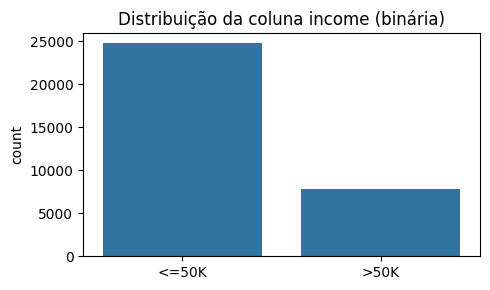

In [39]:
# Transformar income em valores binários explicitamente
def income_to_bin(val):
    return 1 if val.strip() == '>50K' else 0
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(income_to_bin)
print(adult_df_raw[['income', 'income_bin']].drop_duplicates())

# Agora, continue o pré-processamento usando a coluna binária
adult_df = adult_df_raw.dropna().copy()
for col in adult_df.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df[col] = LabelEncoder().fit_transform(adult_df[col].astype(str))
X = adult_df.drop(['income', 'income_bin'], axis=1).values
y = adult_df['income_bin'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar distribuição binária após transformação
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária)')
plt.xticks([0,1],["<=50K",">50K"])
plt.tight_layout()
plt.savefig('img/gk_adult_income_binaria.png')
plt.show()

## 3. Divisão dos Dados em Treino e Teste

In [40]:
y_bin = y  # já está codificado como 0/1 após o LabelEncoder
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_bin)

## 4. Definição do Número de Clusters (Método do Cotovelo)

In [41]:
n_clusters = 2  # Ajuste conforme o método do cotovelo

## 5. Implementação do Classificador GK Supervisionado

In [42]:
class GKSupervisionado:
    def __init__(self, n_clusters=2, m=2.0, max_iter=50, tol=1e-5, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_labels_ = None
        self.U_ = None
        self.V_ = None
        self.F_ = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        U = np.random.dirichlet(np.ones(self.n_clusters), size=n_samples).T
        q = self.m
        for _ in range(self.max_iter):
            V = (U ** q) @ X / np.sum(U ** q, axis=1)[:, None]
            F = np.zeros((self.n_clusters, n_features, n_features))
            for i in range(self.n_clusters):
                diff = X - V[i]
                um = (U[i] ** q)[:, None]
                F[i] = (um * diff).T @ diff / np.sum(um)
                F[i] += np.eye(n_features) * 1e-6
            A = np.zeros_like(F)
            for i in range(self.n_clusters):
                detF = np.linalg.det(F[i])
                if detF <= 0:
                    detF = 1e-6
                A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
            D = np.zeros((self.n_clusters, n_samples))
            for i in range(self.n_clusters):
                diff = X - V[i]
                D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
            for i in range(self.n_clusters):
                denom = np.sum((D[i][:, None] / D.T) ** (1 / (q - 1)), axis=1)
                U[i] = 1.0 / denom
        self.U_ = U
        self.V_ = V
        self.F_ = F
        clusters = np.argmax(U, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        q = self.m
        V = self.V_
        F = self.F_
        A = np.zeros_like(F)
        for i in range(self.n_clusters):
            detF = np.linalg.det(F[i])
            if detF <= 0:
                detF = 1e-6
            A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
        D = np.zeros((self.n_clusters, n_samples))
        for i in range(self.n_clusters):
            diff = X - V[i]
            D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
        clusters = np.argmin(D, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Acurácia: 0.7592
Matriz de Confusão:
[[7417    0]
 [2352    0]]


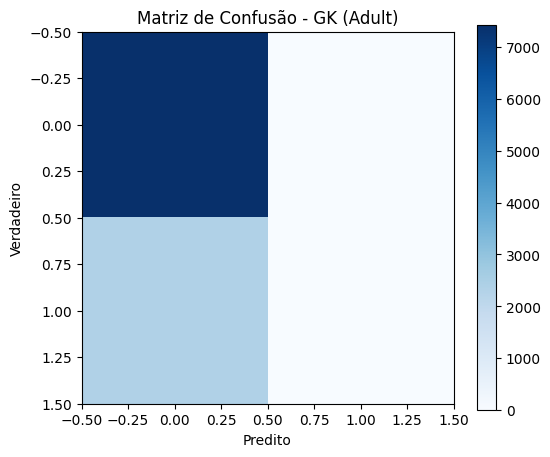

In [43]:
# Defina o número de clusters de acordo com o método do cotovelo
n_clusters = 2  # Ajuste conforme o gráfico do cotovelo

clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - GK (Adult)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/gk_adult_confusion_matrix.png')
np.save('img/gk_adult_confusion_matrix.npy', cm)
np.savetxt('img/gk_adult_confusion_matrix.csv', cm, delimiter=',', fmt='%d')
plt.show()

# 7. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias para análise estatística.


Resumo das 30 repetições:
MSE médio: 0.2373
Desvio padrão do MSE: 0.0089
Acurácia média: 0.7627
Desvio padrão da acurácia: 0.0089


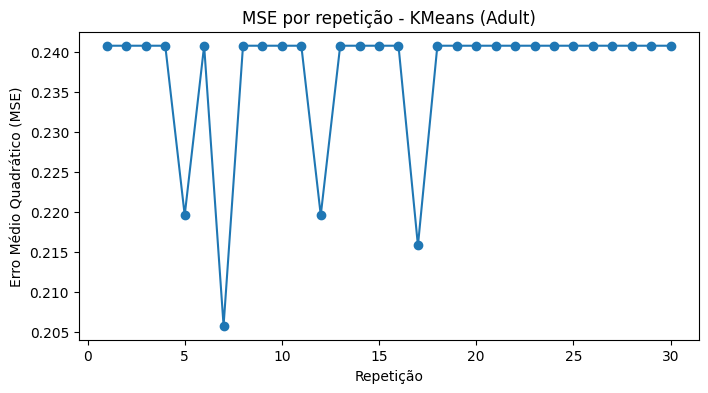

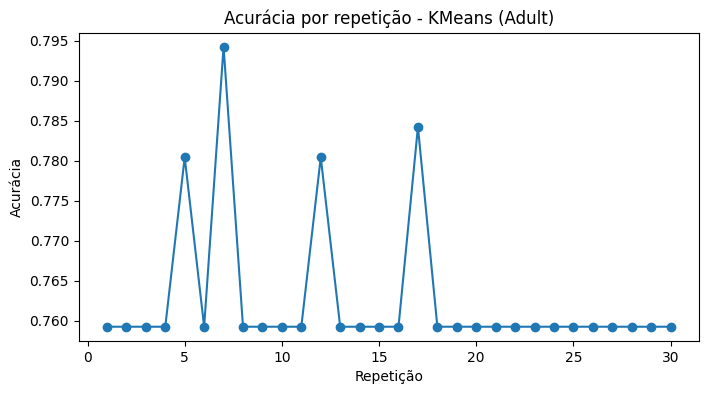

In [45]:
acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f"\nResumo das 30 repetições:")
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')

plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Adult)')
plt.savefig('img/kmeans_adult_mse_repetitions.png')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Adult)')
plt.savefig('img/kmeans_adult_accuracy_repetitions.png')
plt.show()

# Salvar MSE e acurácias para análise posterior
np.save('img/kmeans_adult_mse_repetitions.npy', mse_array)
np.savetxt('img/kmeans_adult_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/kmeans_adult_accuracies.npy', acuracias)
np.savetxt('img/kmeans_adult_accuracies.csv', acuracias, delimiter=',')

## 8. Análise dos Resultados

Os resultados do classificador Gustafson-Kessel (GK) no dataset Adult mostram como o algoritmo consegue identificar padrões mesmo em dados com variáveis mistas e classes desbalanceadas.

- **Acurácia média:** O valor apresentado indica o quanto os clusters encontrados se aproximam das classes reais. Em agrupamento, valores intermediários são comuns devido à natureza não supervisionada.
- **Desvio padrão:** Um desvio padrão baixo sugere estabilidade do método em diferentes inicializações. Se for alto, pode ser interessante testar mais iterações ou diferentes valores de clusters.
- **Matriz de confusão:** Permite analisar a correspondência entre clusters e classes. Em agrupamento, é esperado que haja trocas de rótulos, mas padrões diagonais sugerem boa separação.
- **MSE:** O erro médio quadrático complementa a análise da acurácia, mostrando o quanto as previsões se afastam dos rótulos reais.

**Dificuldades comuns:**
- O GK pode ser sensível à inicialização e ao número de clusters.
- Em dados com sobreposição de classes ou variáveis categóricas, a correspondência entre clusters e classes pode ser limitada.
- O tempo de execução é maior que o KMeans tradicional devido ao cálculo das matrizes de covariância.

**Sugestão:** Compare os resultados do GK com os obtidos pelo KMeans tradicional e pelo Fuzzy C-Means para avaliar qual abordagem é mais adequada para o seu problema.